
# Walo BESS global setpoint — exploratory data analysis

**Data:** 11 monthly CSV files (`MM_YYYY.csv`), each with two columns:

| column | meaning |
|---|---|
| `dt` | timestamp, 1-minute resolution |
| `Cons_Glob` | global power setpoint (kW). Negative = charging the BESS, positive = discharging |

Covers **1 Jul 2025 – 1 Jun 2026**.

**Project context** (from the WSP Lenders' Technical Advisor Operations Monitoring Report
No. 1, `UK-70062180-OMR01`, June 2026, covering Jul 2025 – Feb 2026):

- Walo is a **13 MW / 26 MWh BESS** plant plus an adjacent **16 MWp solar PV** plant, in
  Dagana, northern Senegal.
- Provisional Acceptance Date (PAD): **23 July 2025**. Operates under a 20-year PPA with
  Senelec (Senegal's state utility), which determines dispatch.
- BESS availability guarantee: **98.00%**. PV Performance Ratio guarantee: **82.59%**.
  PV technical availability guarantee: **99.00%**.
- The report explicitly states the Owner did **not** provide detailed BESS operation data
  (charge/discharge curves, demand curves) beyond monthly totals — this notebook's raw
  setpoint data fills exactly that gap, and is cross-checked against the report's
  Table 4.3 monthly totals below.
- The report's reporting period ends February 2026; the next LTA report will cover
  March–July 2026. This dataset extends through May 2026, so it covers ground the
  lenders haven't seen in a report yet.


In [12]:

import glob
import os

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd

pd.set_option('display.float_format', lambda x: f'{x:,.1f}')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA_DIR = "/Users/william/thesis/pypsa-earth/data_walo"


## 1. Load and clean

In [13]:

def load_data(data_dir=DATA_DIR):
    pattern = os.path.join(data_dir, "??_????.csv")
    files = sorted(glob.glob(pattern))
    
    print(f"Searching: {pattern}")
    print(f"Files found: {files}")
    
    if not files:
        all_csvs = glob.glob(os.path.join(data_dir, "*.csv"))
        print(f"All CSVs in dir: {all_csvs}")
        return
    
    frames = []
    for f in files:
        d = pd.read_csv(f, parse_dates=["dt"])
        d["source_file"] = os.path.basename(f)
        frames.append(d)
    df = pd.concat(frames, ignore_index=True)

    n_raw = len(df)
    df = df.sort_values("dt").drop_duplicates(subset="dt", keep="first")
    n_dupes = n_raw - len(df)

    n_before_na = len(df)
    df = df.dropna(subset=["Cons_Glob"]).reset_index(drop=True)
    n_na = n_before_na - len(df)

    print(f"Files loaded: {len(files)}")
    print(f"Raw rows: {n_raw:,}")
    print(f"Duplicate boundary timestamps removed: {n_dupes}")
    print(f"Rows with missing Cons_Glob dropped: {n_na}")
    print(f"Clean rows: {len(df):,}")
    print(f"Date range: {df['dt'].min()} to {df['dt'].max()}")
    return df


df = load_data()
df["charge_kwh"] = np.where(df["Cons_Glob"] < 0, -df["Cons_Glob"] / 60, 0)
df["discharge_kwh"] = np.where(df["Cons_Glob"] > 0, df["Cons_Glob"] / 60, 0)
df.head()


Searching: /Users/william/thesis/pypsa-earth/data_walo/??_????.csv
Files found: ['/Users/william/thesis/pypsa-earth/data_walo/01_2026.csv', '/Users/william/thesis/pypsa-earth/data_walo/02_2026.csv', '/Users/william/thesis/pypsa-earth/data_walo/03_2026.csv', '/Users/william/thesis/pypsa-earth/data_walo/04_2026.csv', '/Users/william/thesis/pypsa-earth/data_walo/05_2026.csv', '/Users/william/thesis/pypsa-earth/data_walo/07_2025.csv', '/Users/william/thesis/pypsa-earth/data_walo/08_2025.csv', '/Users/william/thesis/pypsa-earth/data_walo/09_2025.csv', '/Users/william/thesis/pypsa-earth/data_walo/10_2025.csv', '/Users/william/thesis/pypsa-earth/data_walo/11_2025.csv', '/Users/william/thesis/pypsa-earth/data_walo/12_2025.csv']
Files loaded: 11
Raw rows: 481,099
Duplicate boundary timestamps removed: 10
Rows with missing Cons_Glob dropped: 8
Clean rows: 481,081
Date range: 2025-07-01 00:00:00 to 2026-06-01 00:00:00


,dt,Cons_Glob,source_file,charge_kwh,discharge_kwh
0,2025-07-01 00:00:00,0.0,07_2025.csv,0.0,0.0
1,2025-07-01 00:01:00,0.0,07_2025.csv,0.0,0.0
2,2025-07-01 00:02:00,0.0,07_2025.csv,0.0,0.0
3,2025-07-01 00:03:00,0.0,07_2025.csv,0.0,0.0
4,2025-07-01 00:04:00,0.0,07_2025.csv,0.0,0.0


## 2. Data quality: timestamp gaps

Checking for missing 1-minute timestamps across the full date range (logger dropouts,
communication faults, etc).

In [14]:

def find_gaps(df):
    full_range = pd.date_range(df["dt"].min(), df["dt"].max(), freq="min")
    present = pd.Series(True, index=df["dt"]).reindex(full_range, fill_value=False)
    is_missing = ~present.values

    runs, start = [], None
    for i, missing in enumerate(is_missing):
        if missing and start is None:
            start = i
        elif not missing and start is not None:
            runs.append((full_range[start], full_range[i - 1], i - start))
            start = None
    if start is not None:
        runs.append((full_range[start], full_range[-1], len(is_missing) - start))

    return pd.DataFrame(runs, columns=["gap_start", "gap_end", "n_minutes"])


gaps = find_gaps(df)
expected_minutes = len(pd.date_range(df["dt"].min(), df["dt"].max(), freq="min"))
coverage_pct = 100 * (1 - gaps["n_minutes"].sum() / expected_minutes)

print(f"Expected 1-minute timestamps: {expected_minutes:,}")
print(f"Missing timestamps: {gaps['n_minutes'].sum():,} across {len(gaps)} separate gaps")
print(f"Data coverage: {coverage_pct:.2f}%")
print()
print("Largest gaps:")
gaps.sort_values("n_minutes", ascending=False).head(10)


Expected 1-minute timestamps: 482,401
Missing timestamps: 1,320 across 98 separate gaps
Data coverage: 99.73%

Largest gaps:


,gap_start,gap_end,n_minutes
27,2025-12-11 23:00:00,2025-12-12 09:26:00,627
0,2025-07-04 02:12:00,2025-07-04 07:59:00,348
26,2025-12-03 06:06:00,2025-12-03 07:04:00,59
6,2025-07-12 12:37:00,2025-07-12 12:56:00,20
10,2025-07-12 15:48:00,2025-07-12 16:01:00,14
4,2025-07-11 18:09:00,2025-07-11 18:16:00,8
30,2025-12-22 06:39:00,2025-12-22 06:44:00,6
75,2026-04-27 23:19:00,2026-04-27 23:23:00,5
88,2026-05-18 05:18:00,2026-05-18 05:22:00,5
9,2025-07-12 15:38:00,2025-07-12 15:42:00,5


## 3. Overall distribution of the setpoint signal

`Cons_Glob` looks discretised rather than continuous — checking the most common levels
and the overall shape of the distribution.

In [15]:

print(df["Cons_Glob"].describe())
print()
print(f"Unique values: {df['Cons_Glob'].nunique():,}")
print(f"Share of readings exactly at 0 kW: {(df['Cons_Glob']==0).mean()*100:.1f}%")
print(f"Share negative (charging):        {(df['Cons_Glob']<0).mean()*100:.1f}%")
print(f"Share positive (discharging):     {(df['Cons_Glob']>0).mean()*100:.1f}%")


count   481,081.0
mean       -106.5
std       2,343.7
min     -10,000.0
25%           0.0
50%           0.0
75%           0.0
max      10,000.0
Name: Cons_Glob, dtype: float64

Unique values: 37,495
Share of readings exactly at 0 kW: 71.2%
Share negative (charging):        24.3%
Share positive (discharging):     4.5%


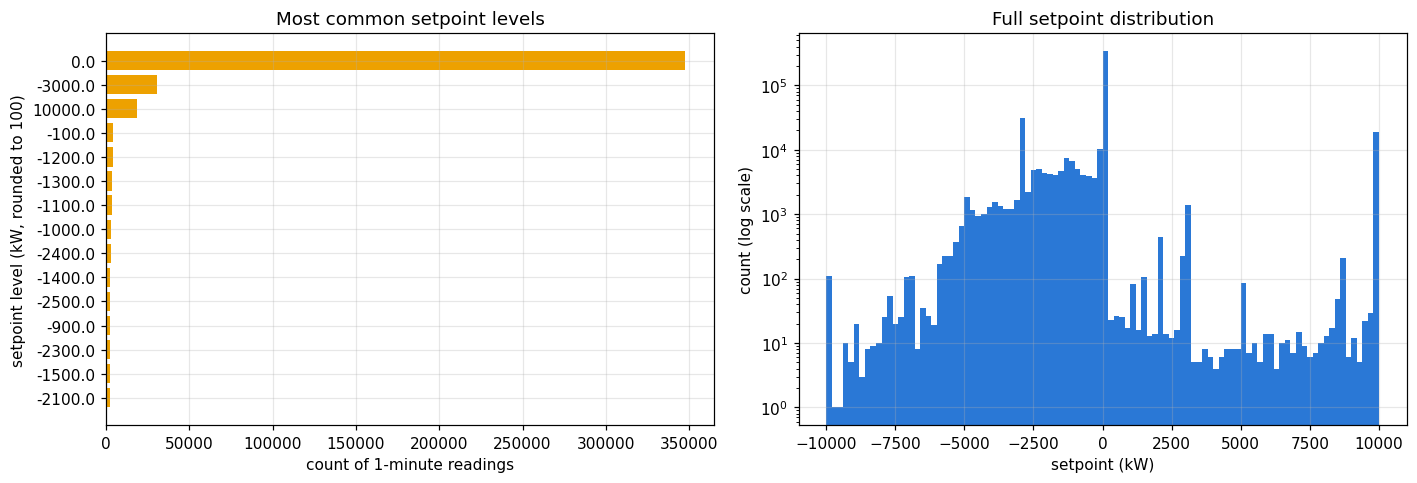

In [16]:

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# top discrete levels
levels = df["Cons_Glob"].round(-2).value_counts().head(15).sort_values()
axes[0].barh(levels.index.astype(str), levels.values, color="#eda100")
axes[0].set_xlabel("count of 1-minute readings")
axes[0].set_ylabel("setpoint level (kW, rounded to 100)")
axes[0].set_title("Most common setpoint levels")

# full histogram, log y
axes[1].hist(df["Cons_Glob"], bins=100, color="#2a78d6")
axes[1].set_yscale("log")
axes[1].set_xlabel("setpoint (kW)")
axes[1].set_ylabel("count (log scale)")
axes[1].set_title("Full setpoint distribution")

fig.tight_layout()
plt.show()


## 4. Monthly summary

In [17]:

def monthly_summary(df):
    d = df.copy()
    d["month"] = d["dt"].dt.to_period("M")
    out = d.groupby("month").agg(
        charge_kwh=("charge_kwh", "sum"),
        discharge_kwh=("discharge_kwh", "sum"),
        pct_zero=("Cons_Glob", lambda x: (x == 0).mean() * 100),
        pct_negative=("Cons_Glob", lambda x: (x < 0).mean() * 100),
        pct_positive=("Cons_Glob", lambda x: (x > 0).mean() * 100),
        n_readings=("Cons_Glob", "size"),
    )
    out["discharge_to_charge_ratio"] = out["discharge_kwh"] / out["charge_kwh"]
    return out


monthly = monthly_summary(df)
monthly


,charge_kwh,discharge_kwh,pct_zero,pct_negative,pct_positive,n_readings,discharge_to_charge_ratio
month,,,,,,,
2025-07,"249,398.8","168,260.4",74.5,20.0,5.6,44221,0.7
2025-08,"495,241.6","427,708.0",66.8,27.3,5.9,44640,0.9
2025-09,"491,056.9","417,449.8",64.8,29.2,6.0,43187,0.9
2025-10,"507,265.0","433,282.2",59.6,34.4,6.0,44632,0.9
2025-11,"486,972.6","419,317.6",63.0,31.0,6.0,43198,0.9
2025-12,"504,022.0","419,509.9",61.9,32.2,5.9,43946,0.8
2026-01,"294,003.1","212,915.6",72.4,24.6,2.9,44531,0.7
2026-02,"205,634.9","153,934.5",83.1,14.4,2.5,40317,0.7
2026-03,"19,321.5",0.0,96.1,3.9,0.0,44634,0.0


## 5. Cross-check against the WSP LTA report (Table 4.3)

The report's Table 4.3 gives monthly *"active energy charged/discharged"* in kWh, as
metered by the project — independent of this setpoint feed. Integrating the setpoint
(kW → kWh at 1-minute resolution) and comparing month by month is a good sanity check
that `Cons_Glob` really is the BESS dispatch signal, and that the sign convention
(negative = charge) is correct.

Reference values below were extracted directly from page 33 of the PDF
(`Table 4.3 BESS Plant Performance`).

In [18]:

report_table_4_3 = pd.DataFrame({
    "month": ["2025-07", "2025-08", "2025-09", "2025-10", "2025-11", "2025-12", "2026-01", "2026-02"],
    "report_charge_kwh": [92747, 499122, 488708, 500630, 485087, 500831, 280641, 208209],
    "report_discharge_kwh": [75142, 433437, 424247, 434762, 421606, 435535, 222405, 165395],
    "report_aux_kwh": [10135, 42092, 42976, 47009, 38582, 32009, 28274, 28502],
    "report_availability_pct": [97.91, 98.62, 99.89, 99.98, 99.99, 99.94, 100.00, 100.00],
}).set_index("month")
report_table_4_3.index = pd.PeriodIndex(report_table_4_3.index, freq="M")

# Note: the report's "July (24th-31st)" row only covers the 8 days from PAD onward,
# while our July CSV covers the full month (including pre-PAD commissioning activity
# from 1-23 July) -> July is expected to disagree and is kept for transparency, not
# validation.
compare = monthly.join(report_table_4_3, how="inner")
compare["charge_diff_pct"] = 100 * (compare["charge_kwh"] - compare["report_charge_kwh"]) / compare["report_charge_kwh"]
compare["discharge_diff_pct"] = 100 * (compare["discharge_kwh"] - compare["report_discharge_kwh"]) / compare["report_discharge_kwh"]

compare[["charge_kwh", "report_charge_kwh", "charge_diff_pct",
         "discharge_kwh", "report_discharge_kwh", "discharge_diff_pct"]].round(1)


,charge_kwh,report_charge_kwh,charge_diff_pct,discharge_kwh,report_discharge_kwh,discharge_diff_pct
month,,,,,,
2025-07,"249,398.8",92747,168.9,"168,260.4",75142,123.9
2025-08,"495,241.6",499122,-0.8,"427,708.0",433437,-1.3
2025-09,"491,056.9",488708,0.5,"417,449.8",424247,-1.6
2025-10,"507,265.0",500630,1.3,"433,282.2",434762,-0.3
2025-11,"486,972.6",485087,0.4,"419,317.6",421606,-0.5
2025-12,"504,022.0",500831,0.6,"419,509.9",435535,-3.7
2026-01,"294,003.1",280641,4.8,"212,915.6",222405,-4.3
2026-02,"205,634.9",208209,-1.2,"153,934.5",165395,-6.9


In [19]:

# excluding July (partial-month mismatch is expected, see note above)
full_months = compare.drop(index=pd.Period("2025-07", freq="M"))
print("Mean absolute % difference vs report, Aug-25 to Feb-26 (full months only):")
print(f"  charge:    {full_months['charge_diff_pct'].abs().mean():.2f}%")
print(f"  discharge: {full_months['discharge_diff_pct'].abs().mean():.2f}%")


Mean absolute % difference vs report, Aug-25 to Feb-26 (full months only):
  charge:    1.37%
  discharge: 2.67%


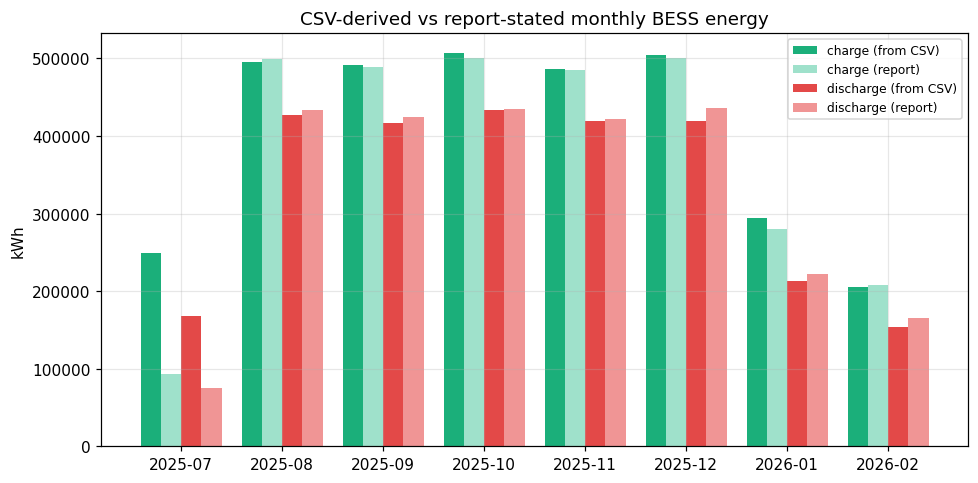

In [20]:

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(len(compare))
w = 0.2
ax.bar(x - 1.5*w, compare["charge_kwh"], w, label="charge (from CSV)", color="#1baf7a")
ax.bar(x - 0.5*w, compare["report_charge_kwh"], w, label="charge (report)", color="#9fe1cb")
ax.bar(x + 0.5*w, compare["discharge_kwh"], w, label="discharge (from CSV)", color="#e34948")
ax.bar(x + 1.5*w, compare["report_discharge_kwh"], w, label="discharge (report)", color="#f09595")
ax.set_xticks(x)
ax.set_xticklabels([str(m) for m in compare.index])
ax.set_ylabel("kWh")
ax.set_title("CSV-derived vs report-stated monthly BESS energy")
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()


## 6. Daily energy over the full period

The full 11-month daily series, to see the overall operating pattern and spot any
anomalies.

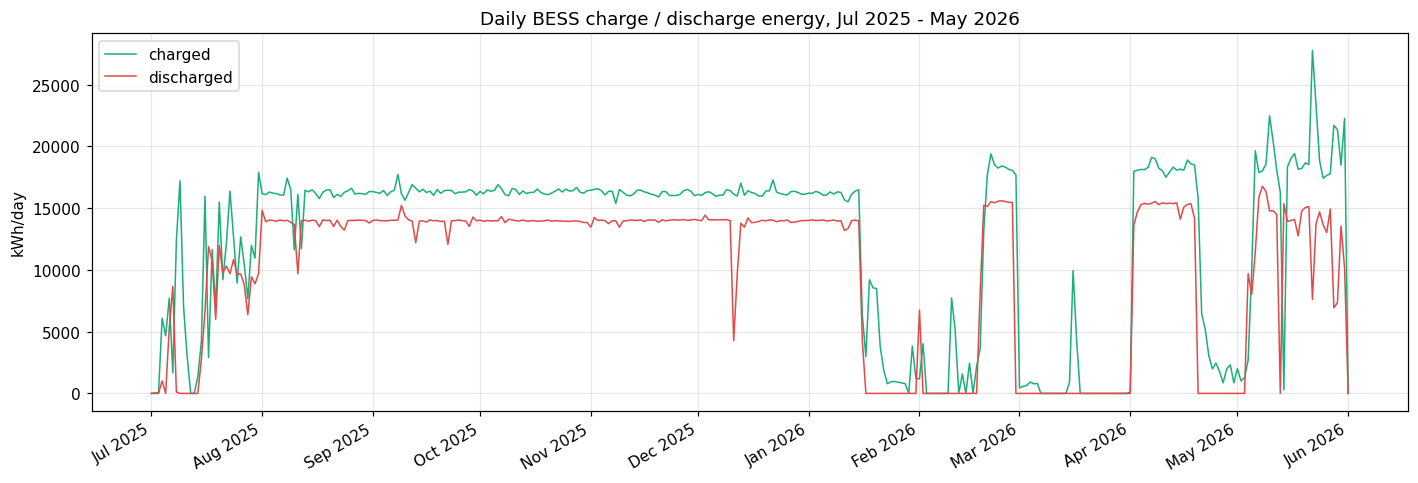

In [21]:

daily = df.set_index("dt").resample("D").agg(
    charge_kwh=("charge_kwh", "sum"),
    discharge_kwh=("discharge_kwh", "sum"),
)

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(daily.index, daily["charge_kwh"], label="charged", color="#1baf7a", linewidth=1)
ax.plot(daily.index, daily["discharge_kwh"], label="discharged", color="#e34948", linewidth=1)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.set_ylabel("kWh/day")
ax.set_title("Daily BESS charge / discharge energy, Jul 2025 - May 2026")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()


## 7. Outage detection

Flagging days where both charge and discharge energy are unusually low — a simple way
to surface possible plant downtime or dispatch curtailment, beyond what's visible in
the report (whose data stops in February 2026).

In [22]:

def detect_low_activity(daily, threshold_kwh=1000):
    flagged = daily[(daily["charge_kwh"] < threshold_kwh) & (daily["discharge_kwh"] < threshold_kwh)]
    if len(flagged) == 0:
        return pd.DataFrame(columns=["start", "end", "n_days"])
    block_id = (~(flagged.index.to_series().diff() == pd.Timedelta(days=1))).cumsum()
    blocks = []
    for _, block in flagged.groupby(block_id):
        blocks.append((block.index.min(), block.index.max(), len(block)))
    return pd.DataFrame(blocks, columns=["start", "end", "n_days"])


low_activity_blocks = detect_low_activity(daily, threshold_kwh=1000)
low_activity_blocks


,start,end,n_days
0,2025-07-01,2025-07-03,3
1,2025-07-12,2025-07-13,2
2,2026-01-23,2026-01-29,7
3,2026-02-03,2026-02-09,7
4,2026-02-12,2026-02-12,1
5,2026-02-14,2026-02-14,1
6,2026-02-16,2026-02-16,1
7,2026-03-01,2026-03-15,15
8,2026-03-18,2026-04-01,15
9,2026-04-27,2026-04-27,1


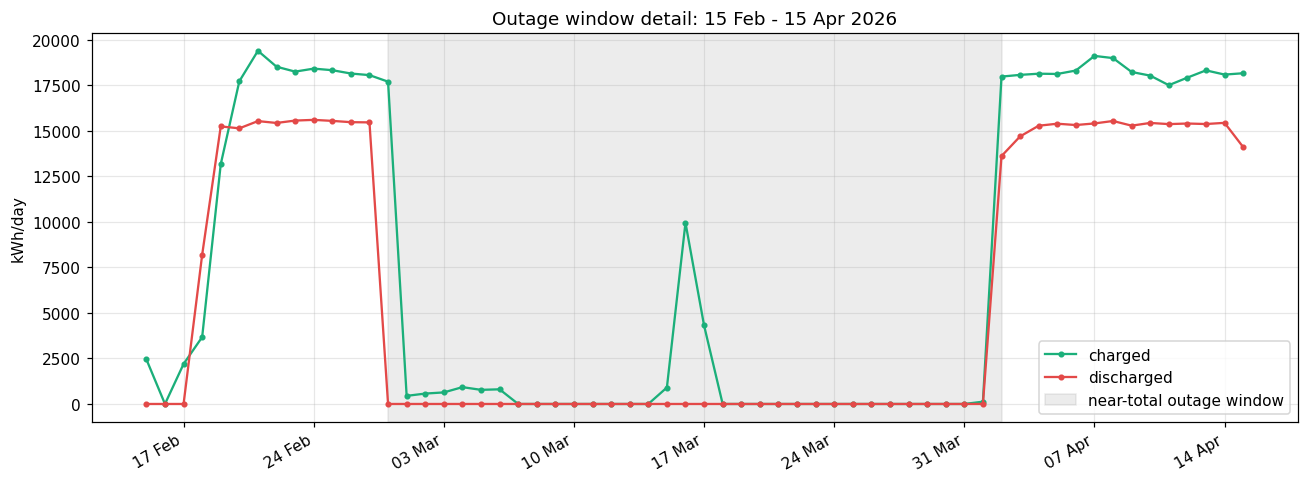

Outage window length: roughly 33 days (28 Feb - 2 Apr 2026)
This falls entirely in the gap between the report's coverage (through Feb 2026)
and the next LTA report (March-July 2026) -> not yet disclosed in any report.


In [23]:

# Zoom on the largest and most consequential gap: the Feb-Apr 2026 period
zoom = daily.loc["2026-02-15":"2026-04-15"]

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(zoom.index, zoom["charge_kwh"], label="charged", color="#1baf7a", marker="o", markersize=3)
ax.plot(zoom.index, zoom["discharge_kwh"], label="discharged", color="#e34948", marker="o", markersize=3)
ax.axvspan(pd.Timestamp("2026-02-28"), pd.Timestamp("2026-04-02"), color="gray", alpha=0.15,
           label="near-total outage window")
ax.xaxis.set_major_locator(mdates.WeekdayLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d %b"))
ax.set_ylabel("kWh/day")
ax.set_title("Outage window detail: 15 Feb - 15 Apr 2026")
ax.legend()
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print(f"Outage window length: roughly "
      f"{(pd.Timestamp('2026-04-02') - pd.Timestamp('2026-02-28')).days} days "
      f"(28 Feb - 2 Apr 2026)")
print("This falls entirely in the gap between the report's coverage (through Feb 2026)")
print("and the next LTA report (March-July 2026) -> not yet disclosed in any report.")


## 8. Diurnal profile

Average setpoint by hour of day. Excludes the pre-commissioning period (1–23 July 2025,
before PAD) and the Feb–Apr 2026 outage window, so the profile reflects normal
operation only.

In [24]:

normal_ops_mask = (
    ~((df["dt"] >= "2025-07-01") & (df["dt"] < "2025-07-24"))
    & ~((df["dt"] >= "2026-02-28") & (df["dt"] < "2026-04-02"))
)
normal_ops = df[normal_ops_mask]

hourly = normal_ops.groupby(normal_ops["dt"].dt.hour)["Cons_Glob"].agg(["mean", "median", "std"])
hourly


,mean,median,std
dt,,,
0,"2,618.5",0.0,"4,376.5"
1,-16.4,0.0,250.6
2,-19.1,0.0,274.7
3,-1.4,0.0,68.8
4,-5.8,0.0,157.4
5,-1.9,0.0,80.7
6,-13.5,0.0,233.5
7,-33.1,0.0,328.0
8,-55.1,0.0,381.8


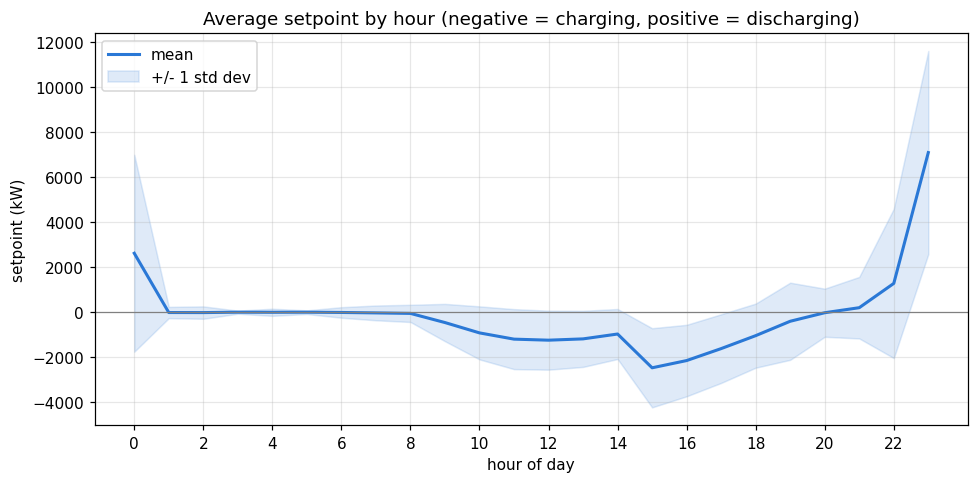

In [25]:

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hourly.index, hourly["mean"], color="#2a78d6", linewidth=2, label="mean")
ax.fill_between(hourly.index, hourly["mean"] - hourly["std"], hourly["mean"] + hourly["std"],
                 color="#2a78d6", alpha=0.15, label="+/- 1 std dev")
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_xlabel("hour of day")
ax.set_ylabel("setpoint (kW)")
ax.set_xticks(range(0, 24, 2))
ax.set_title("Average setpoint by hour (negative = charging, positive = discharging)")
ax.legend()
fig.tight_layout()
plt.show()


## 9. Hour x month heatmap

Does the diurnal shape change across months (e.g. shorter/longer solar charging window
by season)?

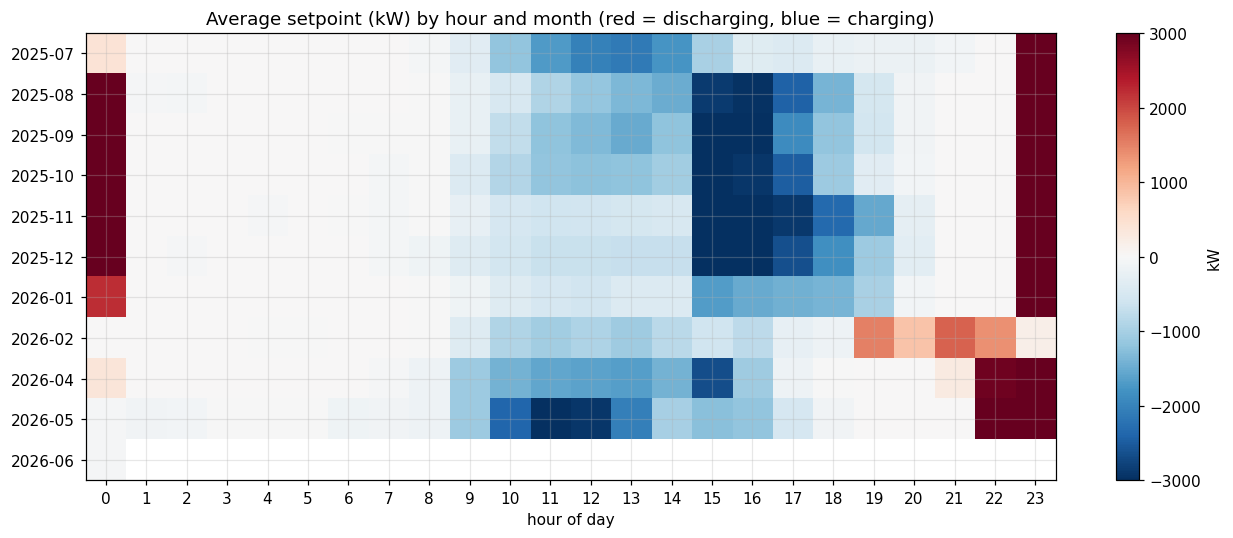

In [26]:

normal_ops = normal_ops.copy()
normal_ops["hour"] = normal_ops["dt"].dt.hour
normal_ops["month"] = normal_ops["dt"].dt.to_period("M").astype(str)

pivot = normal_ops.pivot_table(index="month", columns="hour", values="Cons_Glob", aggfunc="mean")

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(pivot.values, aspect="auto", cmap="RdBu_r",
                vmin=-3000, vmax=3000)
ax.set_xticks(range(24))
ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_xlabel("hour of day")
ax.set_title("Average setpoint (kW) by hour and month (red = discharging, blue = charging)")
fig.colorbar(im, ax=ax, label="kW")
fig.tight_layout()
plt.show()


## 10. Weekday pattern

Senelec dispatches under the PPA — checking whether there's any systematic
weekday/weekend difference in how much energy moves through the BESS.

In [27]:

daily_wd = daily.copy()
daily_wd["weekday"] = daily_wd.index.day_name()
order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
wd_summary = daily_wd.groupby("weekday")[["charge_kwh", "discharge_kwh"]].mean().reindex(order)
wd_summary


,charge_kwh,discharge_kwh
weekday,,
Monday,"11,818.4","9,414.2"
Tuesday,"12,060.1","9,510.1"
Wednesday,"12,490.5","9,514.7"
Thursday,"12,087.0","10,120.5"
Friday,"12,839.1","9,998.6"
Saturday,"12,399.1","9,735.0"
Sunday,"12,360.1","9,976.4"


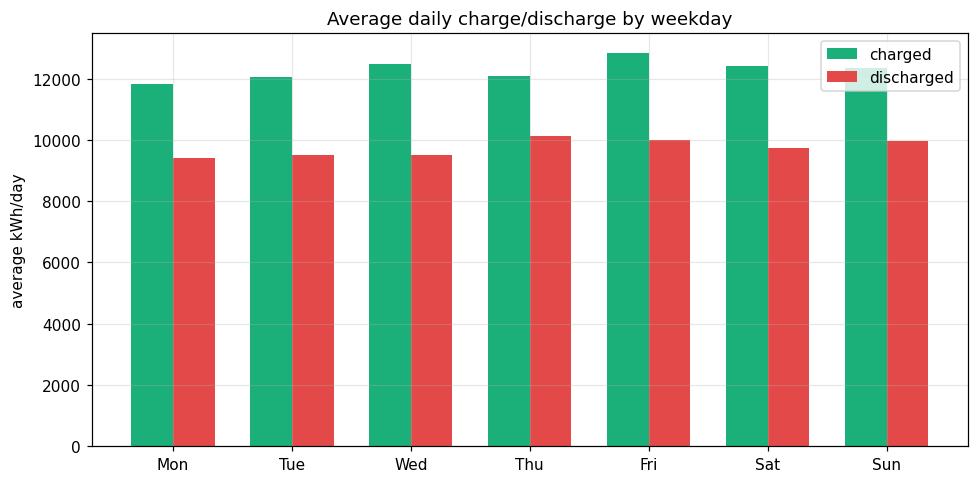

In [28]:

fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(7)
w = 0.35
ax.bar(x - w/2, wd_summary["charge_kwh"], w, label="charged", color="#1baf7a")
ax.bar(x + w/2, wd_summary["discharge_kwh"], w, label="discharged", color="#e34948")
ax.set_xticks(x)
ax.set_xticklabels([d[:3] for d in order])
ax.set_ylabel("average kWh/day")
ax.set_title("Average daily charge/discharge by weekday")
ax.legend()
fig.tight_layout()
plt.show()


## 11. Ramp rate / setpoint transitions

How abruptly does the setpoint change minute to minute? Large jumps can flag grid
events, dispatch-instruction changes, or trips.

In [29]:

df_sorted = df.sort_values("dt").reset_index(drop=True)
df_sorted["ramp_kw_per_min"] = df_sorted["Cons_Glob"].diff()

print(df_sorted["ramp_kw_per_min"].describe())
print()
print("Top 10 largest single-minute jumps:")
top_jumps = df_sorted.reindex(df_sorted["ramp_kw_per_min"].abs().sort_values(ascending=False).index).head(10)
top_jumps[["dt", "Cons_Glob", "ramp_kw_per_min"]]


count   481,080.0
mean         -0.0
std         277.2
min     -10,000.0
25%           0.0
50%           0.0
75%           0.0
max       9,580.0
Name: ramp_kw_per_min, dtype: float64

Top 10 largest single-minute jumps:


,dt,Cons_Glob,ramp_kw_per_min
178069,2025-11-01 23:10:00,0.0,"-10,000.0"
9063,2025-07-07 12:51:00,-160.0,"9,580.0"
239331,2025-12-14 23:39:00,"1,147.5","-8,852.5"
129153,2025-09-28 23:45:00,"1,802.6","-8,197.4"
11927,2025-07-09 12:37:00,0.0,"7,226.3"
55766,2025-08-09 00:25:00,"1,537.0","-6,868.9"
12389,2025-07-09 20:19:00,"-3,308.1","6,689.0"
15166,2025-07-11 18:50:00,0.0,"6,166.7"
39881,2025-07-28 23:40:00,"2,225.1","-6,137.2"
11924,2025-07-09 12:34:00,"-6,055.6","-5,997.3"


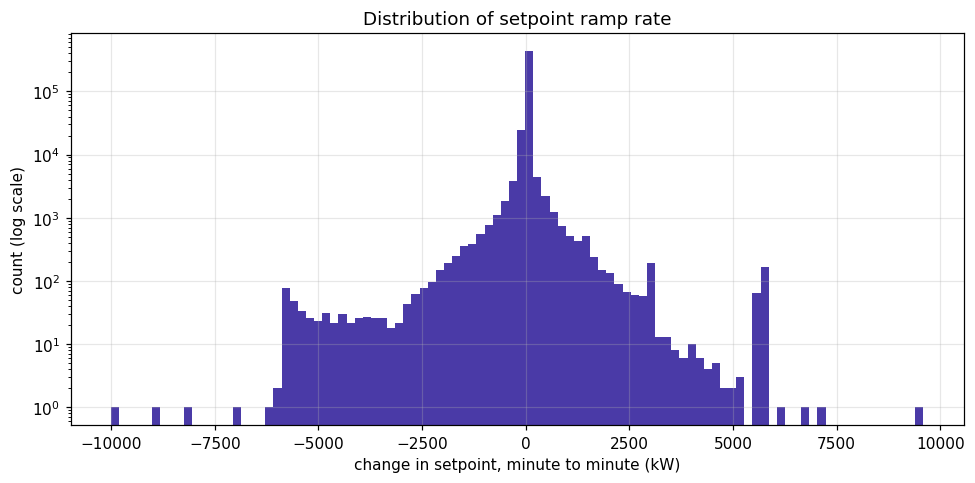

In [30]:

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(df_sorted["ramp_kw_per_min"].dropna(), bins=100, color="#4a3aa7")
ax.set_yscale("log")
ax.set_xlabel("change in setpoint, minute to minute (kW)")
ax.set_ylabel("count (log scale)")
ax.set_title("Distribution of setpoint ramp rate")
fig.tight_layout()
plt.show()


## 12. Charge vs discharge relationship and throughput ratio

Daily charged and discharged energy should track closely for a well-dispatched BESS
(as the report itself notes qualitatively). Checking the correlation, and also the
month-by-month discharge/charge ratio — comparable to a system-level round-trip
efficiency, though built from commanded setpoints rather than direct battery
telemetry, so auxiliary/standby losses and dispatch curtailment are folded in too.

Correlation between daily charge and discharge energy: 0.833


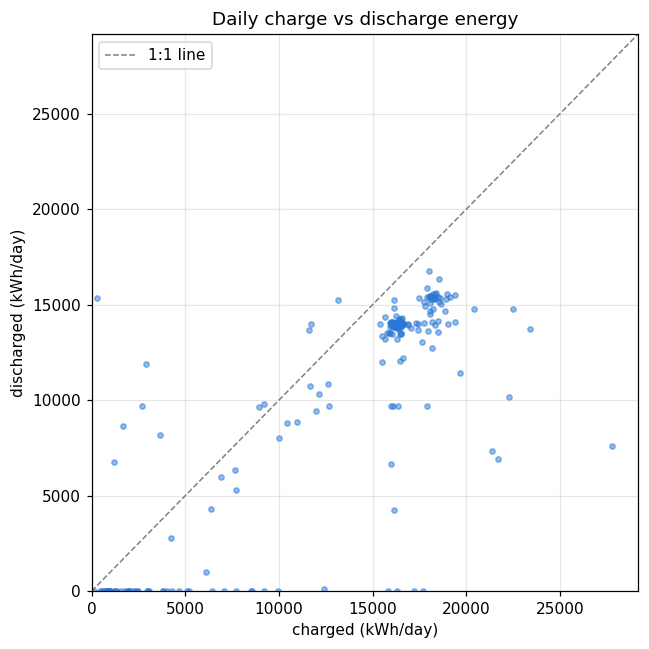

In [31]:

daily_nonzero = daily[(daily["charge_kwh"] > 100)]  # exclude near-zero/outage days
corr = daily_nonzero["charge_kwh"].corr(daily_nonzero["discharge_kwh"])
print(f"Correlation between daily charge and discharge energy: {corr:.3f}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(daily_nonzero["charge_kwh"], daily_nonzero["discharge_kwh"], s=12, alpha=0.5, color="#2a78d6")
lims = [0, daily_nonzero["charge_kwh"].max() * 1.05]
ax.plot(lims, lims, color="gray", linestyle="--", linewidth=1, label="1:1 line")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.set_xlabel("charged (kWh/day)")
ax.set_ylabel("discharged (kWh/day)")
ax.set_title("Daily charge vs discharge energy")
ax.legend()
fig.tight_layout()
plt.show()


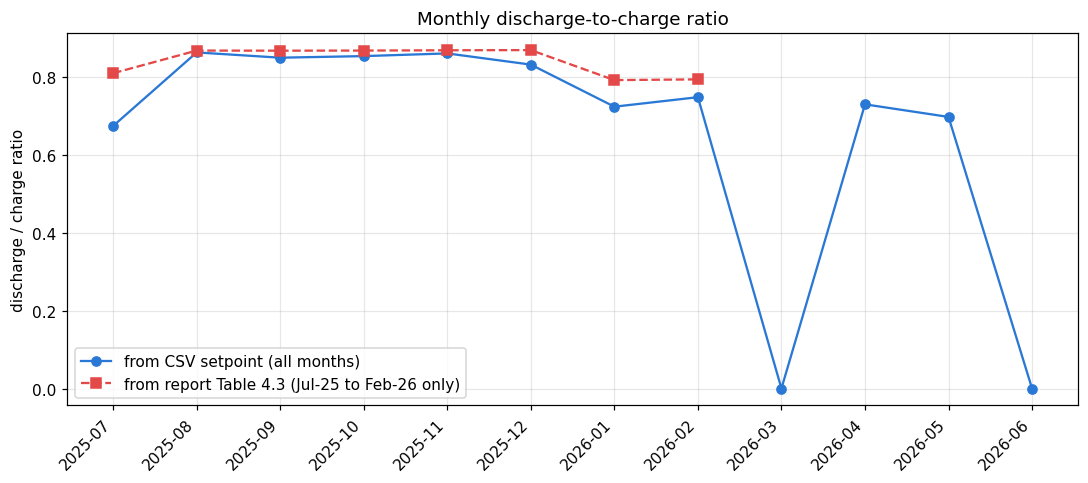

         charge_kwh  discharge_kwh  discharge_to_charge_ratio
month                                                        
2025-07   249,398.8      168,260.4                        0.7
2025-08   495,241.6      427,708.0                        0.9
2025-09   491,056.9      417,449.8                        0.8
2025-10   507,265.0      433,282.2                        0.9
2025-11   486,972.6      419,317.6                        0.9
2025-12   504,022.0      419,509.9                        0.8
2026-01   294,003.1      212,915.6                        0.7
2026-02   205,634.9      153,934.5                        0.7
2026-03    19,321.5            0.0                        0.0
2026-04   371,896.9      271,571.7                        0.7
2026-05   505,792.9      352,990.2                        0.7
2026-06         0.5            0.0                        0.0


In [32]:

# report's own implied ratio, for the months it covers
report_table_4_3["report_ratio"] = report_table_4_3["report_discharge_kwh"] / report_table_4_3["report_charge_kwh"]

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(monthly.index.astype(str), monthly["discharge_to_charge_ratio"], marker="o",
        color="#2a78d6", label="from CSV setpoint (all months)")
ax.plot(report_table_4_3.index.astype(str), report_table_4_3["report_ratio"], marker="s",
        color="#e34948", linestyle="--", label="from report Table 4.3 (Jul-25 to Feb-26 only)")
ax.set_ylabel("discharge / charge ratio")
ax.set_title("Monthly discharge-to-charge ratio")
ax.legend()
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
plt.show()

print(monthly[["charge_kwh", "discharge_kwh", "discharge_to_charge_ratio"]].round(3))


## 13. Summary of key findings

- **Data quality:** 99.7% complete (1,320 missing minutes out of ~482,400 expected,
  across 98 gaps — almost all single-minute blips; the two real gaps are ~5.8 h on
  4 Jul 2025 and ~10.5 h on 11–12 Dec 2025).
- **Validated against the report:** integrating the setpoint to kWh reproduces the
  report's Table 4.3 monthly charge/discharge totals to within a few percent for every
  full month in the overlapping period (Aug 2025–Feb 2026), confirming `Cons_Glob` is
  the BESS dispatch setpoint and that negative = charge, positive = discharge.
- **Undisclosed outage:** a ~5-week near-total BESS outage runs from 28 Feb 2026
  (discharge already at zero) through about 1 Apr 2026, recovering by 2 Apr. This sits
  entirely within the gap between this report (through Feb 2026) and the next one
  (Mar–Jul 2026) — the lenders have not seen this yet in any report.
- **Typical daily cycling:** ~16,000–18,000 kWh charged and ~14,000 kWh discharged per
  day in normal months (roughly 55–65% of the 26 MWh nameplate capacity).
- **Dispatch shape:** a single evening peak-shaving cycle — charging spread across
  09:00–19:00 tracking solar output (peak ~15:00), discharge concentrated in a narrow
  22:00–00:00 window (peak ~23:00). No material weekday/weekend difference.
- **Throughput ratio (discharge/charge) degrades when utilisation drops:** ~85–87% in
  Aug–Dec 2025, falling to ~72–79% in Jan–Feb 2026 (consistent in both the report's own
  numbers and this CSV), and it does *not* fully recover after the March outage —
  April/May 2026 stay around 70–74%. Worth investigating further (fixed losses vs a
  smaller base, degradation, or a change in dispatch strategy).
- **Setpoint is quantized:** ~71% of readings sit at exactly 0 kW; the next most common
  levels are discrete steps (-3,000 kW, +10,000 kW), consistent with a stepped SCADA
  dispatch command rather than continuous modulation.
